In [1]:
import os
import cv2  # For image processing and face detection
import numpy as np
import matplotlib.pyplot as plt

# Import classifiers and evaluation tools from scikit-learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV  # For parameter tuning with cross-validation
from sklearn.metrics import confusion_matrix, accuracy_score

# Configuration parameters
IMG_SIZE = 64  # Final face image size (width and height after resizing)

# Load OpenCV's pre-trained Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Dataset base directories (each should contain two folders: "man" and "woman")
train_base_dir = '/kaggle/input/gender-detection-and-classification-image-dataset/train/'
test_base_dir  = '/kaggle/input/gender-detection-and-classification-image-dataset/test/'

print('Step 1 executed')

Step 1 executed


In [2]:
def extract_face_features(image_path, img_size=IMG_SIZE):
    """
    Reads an image, detects a face using Haar cascades, extracts the face region,
    converts it to grayscale, resizes it to a fixed size, and flattens the image into a feature vector.
    
    Parameters:
        image_path (str): Path to the image file.
        img_size (int): Target size for the face image.
    
    Returns:
        np.array: 1D feature vector of pixel intensities, or None if no face is detected.
    """
    # Read the image from the file
    img = cv2.imread(image_path)
    if img is None:
        return None

    # Convert the image to grayscale (needed for Haar cascade detection)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect faces in the image
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    if len(faces) == 0:
        return None

    # Use the first detected face (for simplicity)
    (x, y, w, h) = faces[0]
    face_roi = gray[y:y+h, x:x+w]
    
    # Resize the face region to a fixed size
    face_resized = cv2.resize(face_roi, (img_size, img_size))
    
    # Flatten the image to create a feature vector
    features = face_resized.flatten()
    return features

def load_dataset_from_folder(folder_path, label):
    """
    Loads images from a folder, extracts face features, and assigns a label.
    
    Parameters:
        folder_path (str): Directory path containing images.
        label (int): Label to assign to each image (e.g., 0 for man, 1 for woman).
    
    Returns:
        list, list: Lists of feature vectors and corresponding labels.
    """
    features_list = []
    labels_list = []
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(folder_path, filename)
            features = extract_face_features(image_path)
            if features is not None:
                features_list.append(features)
                labels_list.append(label)
    return features_list, labels_list
print('Step 2 executed')

Step 2 executed


In [3]:

# --- Load Training Data ---
# Define paths for "man" and "woman" folders in training data
train_man_dir   = os.path.join(train_base_dir, 'men')
train_woman_dir = os.path.join(train_base_dir, 'women')

# Load images and extract features; label 0 for "man", 1 for "woman"
features_man,   labels_man   = load_dataset_from_folder(train_man_dir, 0)
features_woman, labels_woman = load_dataset_from_folder(train_woman_dir, 1)

# Combine training data from both classes
train_features = features_man + features_woman
train_labels   = labels_man + labels_woman

# --- Load Testing Data ---
# Define paths for "man" and "woman" folders in test data
test_man_dir   = os.path.join(test_base_dir, 'men')
test_woman_dir = os.path.join(test_base_dir, 'women')

# Load test images and extract features
features_man_test,   labels_man_test   = load_dataset_from_folder(test_man_dir, 0)
features_woman_test, labels_woman_test = load_dataset_from_folder(test_woman_dir, 1)

# Combine test data from both classes
test_features = features_man_test + features_woman_test
test_labels   = labels_man_test + labels_woman_test

# Convert lists to NumPy arrays for compatibility with scikit-learn
X_train = np.array(train_features)
y_train = np.array(train_labels)
X_test  = np.array(test_features)
y_test  = np.array(test_labels)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)


Training features shape: (218, 4096)
Testing features shape: (78, 4096)


In [4]:
# --- Tuning K-NN Classifier ---
knn = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],       # Trying different neighbor counts
    'weights': ['uniform', 'distance'] # Different weighting schemes
}
# Use 5-fold cross-validation to search for the best hyperparameters
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_  # Best K-NN model after tuning
print("Best K-NN parameters:", grid_knn.best_params_)

# --- Tuning Decision Tree Classifier ---
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'max_depth': [None, 5, 10, 15],       # Maximum depth of the tree
    'min_samples_split': [2, 5, 10]        # Minimum samples required to split a node
}
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
print("Best Decision Tree parameters:", grid_dt.best_params_)

# --- Tuning Random Forest Classifier ---
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 150],       # Number of trees in the forest
    'max_depth': [None, 5, 10, 15]          # Maximum depth of the trees
}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print("Best Random Forest parameters:", grid_rf.best_params_)



Best K-NN parameters: {'n_neighbors': 3, 'weights': 'uniform'}
Best Decision Tree parameters: {'max_depth': None, 'min_samples_split': 5}
Best Random Forest parameters: {'max_depth': 5, 'n_estimators': 150}


In [5]:
# --- Evaluate Tuned K-NN Model ---
y_pred_knn = best_knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("Tuned K-NN Test Accuracy: {:.4f}".format(knn_accuracy))
cm_knn = confusion_matrix(y_test, y_pred_knn)

# --- Evaluate Tuned Decision Tree Model ---
y_pred_dt = best_dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Tuned Decision Tree Test Accuracy: {:.4f}".format(dt_accuracy))
cm_dt = confusion_matrix(y_test, y_pred_dt)

# --- Evaluate Tuned Random Forest Model ---
y_pred_rf = best_rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Tuned Random Forest Test Accuracy: {:.4f}".format(rf_accuracy))
cm_rf = confusion_matrix(y_test, y_pred_rf)


Tuned K-NN Test Accuracy: 0.6410
Tuned Decision Tree Test Accuracy: 0.7051
Tuned Random Forest Test Accuracy: 0.6923


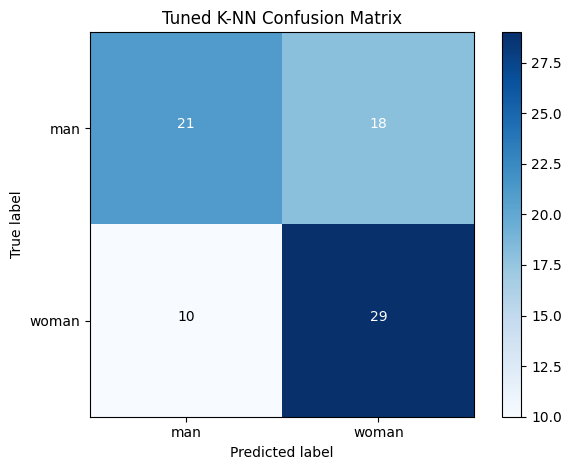

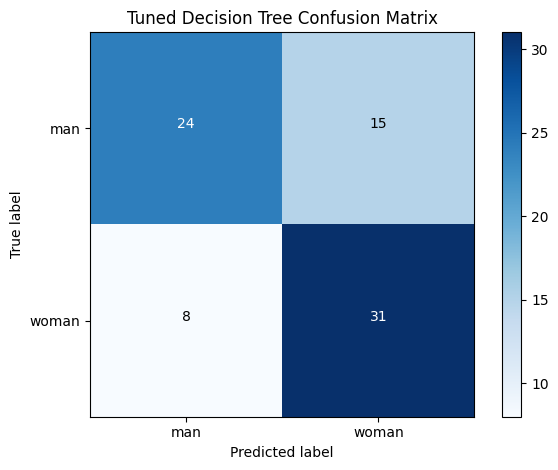

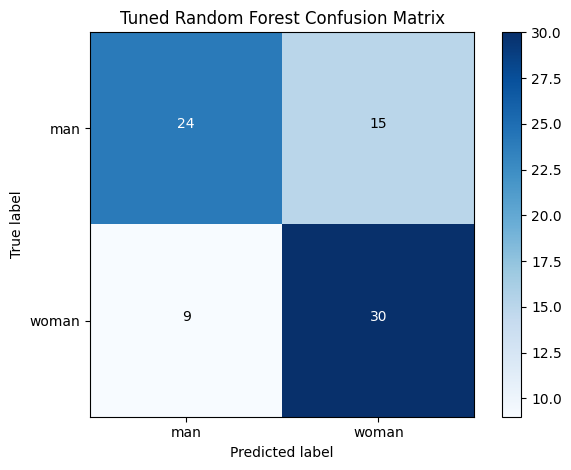

In [6]:
def plot_confusion_matrix(cm, title):
    """
    Plots a confusion matrix using matplotlib.
    
    Parameters:
        cm (np.array): Confusion matrix.
        title (str): Title for the plot.
    """
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(2)  # Two classes: "man" and "woman"
    plt.xticks(tick_marks, ['man', 'woman'])
    plt.yticks(tick_marks, ['man', 'woman'])
    
    thresh = cm.max() / 2.
    # Annotate each cell in the confusion matrix with its value
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Plot confusion matrices for all tuned classifiers
plot_confusion_matrix(cm_knn, "Tuned K-NN Confusion Matrix")
plot_confusion_matrix(cm_dt, "Tuned Decision Tree Confusion Matrix")
plot_confusion_matrix(cm_rf, "Tuned Random Forest Confusion Matrix")


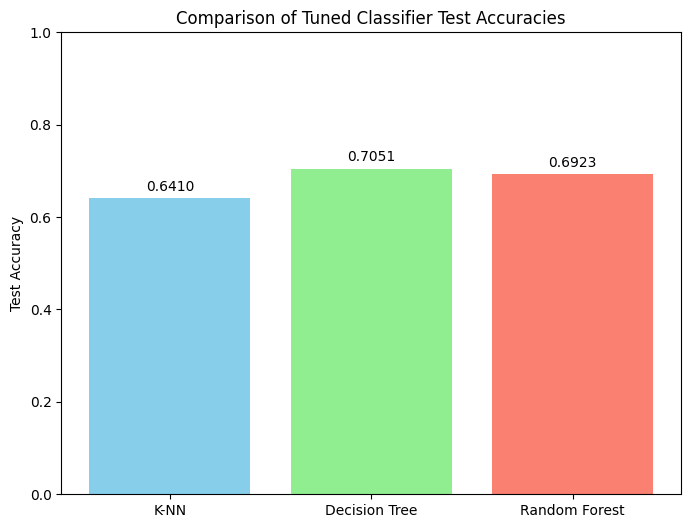

In [7]:
# Define classifier names and their corresponding test accuracies
classifiers = ['K-NN', 'Decision Tree', 'Random Forest']
accuracies = [knn_accuracy, dt_accuracy, rf_accuracy]

plt.figure(figsize=(8, 6))
bars = plt.bar(classifiers, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1)  # Accuracy is between 0 and 1
plt.ylabel('Test Accuracy')
plt.title('Comparison of Tuned Classifier Test Accuracies')

# Add text labels above each bar to display the accuracy value
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom')

plt.show()
